Saving Experiments_5_7_ML_Dataset.csv to Experiments_5_7_ML_Dataset (1).csv
Dataset shape: (500, 9)


,StudyHours,Attendance,AssignmentsCompleted,PreviousScore,SleepHours,InternetUsageHours,PracticeTests,FinalScore,PlacementStatus
0,4.37,86.42,9,51.86,7.18,4.17,0,85.58,1
1,9.56,79.12,4,76.24,7.93,3.51,1,101.26,1
2,7.59,68.93,9,61.66,4.59,7.95,10,101.35,1
3,6.39,91.62,6,75.82,6.05,7.10,8,109.08,1
4,2.40,85.81,2,45.86,8.20,5.18,8,67.22,0


Gini Accuracy: 0.81
Entropy Accuracy: 0.87


,Criterion,Accuracy
0,Gini,0.81
1,Entropy,0.87


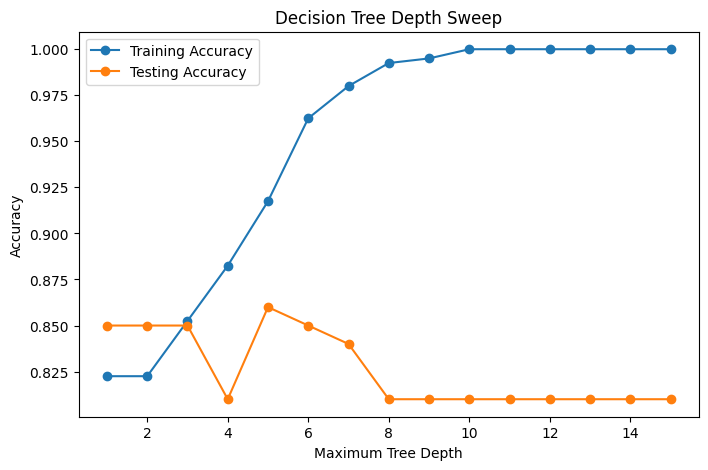

Best Depth: 5
Best Test Accuracy: 0.86
Number of CCP alpha values: 26

Best CCP Alpha: 0.006233766233766232
Best Pruned Accuracy: 0.89


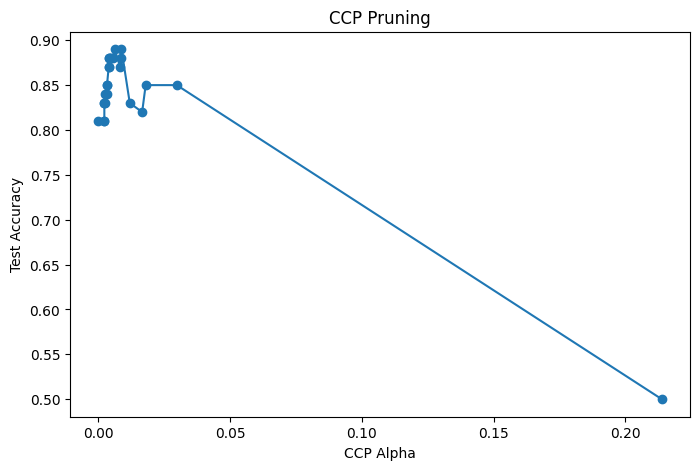


Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.88      0.89        50
           1       0.88      0.90      0.89        50

    accuracy                           0.89       100
   macro avg       0.89      0.89      0.89       100
weighted avg       0.89      0.89      0.89       100



In [1]:
# ============================================
# EXPERIMENT 6
# Decision Tree
# Splitting Criteria, CCP Pruning and Depth Sweep
# ============================================

# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Step 2: Upload CSV
uploaded = files.upload()

# Step 3: Read dataset
df = pd.read_csv("Experiments_5_7_ML_Dataset.csv")

print("Dataset shape:", df.shape)
display(df.head())

# Step 4: Select features and target
X = df.drop(columns=["FinalScore", "PlacementStatus"])
y = df["PlacementStatus"]

# Step 5: Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ============================================
# PART A: GINI vs ENTROPY
# ============================================

# Step 6: Decision Tree using Gini
tree_gini = DecisionTreeClassifier(
    criterion="gini",
    max_depth=4,
    random_state=42
)

tree_gini.fit(X_train, y_train)

gini_pred = tree_gini.predict(X_test)

gini_accuracy = accuracy_score(y_test, gini_pred)

print("Gini Accuracy:", round(gini_accuracy, 4))

# Step 7: Decision Tree using Entropy
tree_entropy = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=4,
    random_state=42
)

tree_entropy.fit(X_train, y_train)

entropy_pred = tree_entropy.predict(X_test)

entropy_accuracy = accuracy_score(y_test, entropy_pred)

print("Entropy Accuracy:", round(entropy_accuracy, 4))

# Compare
comparison = pd.DataFrame({
    "Criterion": ["Gini", "Entropy"],
    "Accuracy": [gini_accuracy, entropy_accuracy]
})

display(comparison)

# ============================================
# PART B: DEPTH SWEEP
# ============================================

depths = range(1, 16)

train_accuracy = []
test_accuracy = []

for depth in depths:

    model = DecisionTreeClassifier(
        criterion="gini",
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_accuracy.append(
        accuracy_score(y_train, train_pred)
    )

    test_accuracy.append(
        accuracy_score(y_test, test_pred)
    )

# Step 8: Plot depth sweep
plt.figure(figsize=(8,5))

plt.plot(depths, train_accuracy, marker="o", label="Training Accuracy")
plt.plot(depths, test_accuracy, marker="o", label="Testing Accuracy")

plt.xlabel("Maximum Tree Depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree Depth Sweep")
plt.legend()

plt.show()

# Step 9: Find best depth
best_index = np.argmax(test_accuracy)
best_depth = list(depths)[best_index]

print("Best Depth:", best_depth)
print("Best Test Accuracy:", round(test_accuracy[best_index], 4))

# ============================================
# PART C: CCP PRUNING
# ============================================

# Step 10: Get pruning path
initial_tree = DecisionTreeClassifier(
    random_state=42
)

initial_tree.fit(X_train, y_train)

path = initial_tree.cost_complexity_pruning_path(
    X_train, y_train
)

ccp_alphas = path.ccp_alphas

print("Number of CCP alpha values:", len(ccp_alphas))

# Step 11: Train trees using different alpha values
pruned_models = []

for alpha in ccp_alphas:

    model = DecisionTreeClassifier(
        random_state=42,
        ccp_alpha=alpha
    )

    model.fit(X_train, y_train)

    pruned_models.append(model)

# Step 12: Calculate accuracy
pruned_accuracy = []

for model in pruned_models:

    prediction = model.predict(X_test)

    accuracy = accuracy_score(
        y_test,
        prediction
    )

    pruned_accuracy.append(accuracy)

# Step 13: Find best pruning value
best_prune_index = np.argmax(pruned_accuracy)

best_alpha = ccp_alphas[best_prune_index]
best_pruned_accuracy = pruned_accuracy[best_prune_index]

print("\nBest CCP Alpha:", best_alpha)
print("Best Pruned Accuracy:", round(best_pruned_accuracy, 4))

# Step 14: Plot CCP pruning
plt.figure(figsize=(8,5))

plt.plot(
    ccp_alphas,
    pruned_accuracy,
    marker="o"
)

plt.xlabel("CCP Alpha")
plt.ylabel("Test Accuracy")
plt.title("CCP Pruning")

plt.show()

# Step 15: Classification report
best_tree = pruned_models[best_prune_index]

final_pred = best_tree.predict(X_test)

print("\nClassification Report:")
print(classification_report(y_test, final_pred))